  We've got our 5 PCA components, five clean axes describing the market on any given day.
  Now let's group the days that look alike. K-means takes those 5 coordinates and sorts every day into a regime, so that instead of forcing one VaR onto all conditions, we can eventually treat each regime on its own terms.

 The regime label we produce here will become a feature in the XGBoost VaR model (notebook 04). It gives the model the coarse "what kind of market is this?" context, and the continuous features fine-tune the VaR within it.

  The thing we'll keep our eye on: we build these regimes without ever looking at the DFL, then check afterwards whether the DFL actually behaves differently from one regime to the next.
  If it does, the whole regime-conditional idea earns its place.

In [154]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)
print("Setup OK")



Setup OK


In [155]:
# Cell 2 — Load PCA scores (for clustering) + master dataset (for DFL analysis)

pca_scores = pd.read_pickle("../data/processed/pca_scores.pkl")
df = pd.read_pickle("../data/master_dataset.pkl")

print(f"PCA scores : {pca_scores.shape}  ({pca_scores.index.min().date()} → {pca_scores.index.max().date()})")
print(f"Master     : {df.shape}")
print()

# Align the DFL onto the PCA-scores dates (clustering window)
dfl = df.loc[pca_scores.index, "DFL"]
print(f"DFL aligned on clustering window: {dfl.notna().sum()} non-NaN values")
print()
print(pca_scores.head(3))

PCA scores : (3035, 5)  (2014-01-30 → 2026-05-06)
Master     : (3055, 44)

DFL aligned on clustering window: 3015 non-NaN values

             PC1    PC2    PC3    PC4   PC5
date                                       
2014-01-30 0.170 -1.728 -0.338 -0.227 2.991
2014-01-31 0.236 -1.795 -0.100 -0.558 2.481
2014-02-03 0.304 -1.405 -0.241  0.111 2.929


We made sure that PCA and DFL have the same dates.

Let's choose how many regime we will have by using elbow plot (where does adding clusters stop reducing the spread inside each one?) and the silhouette score (how cleanly separated are the clusters?).

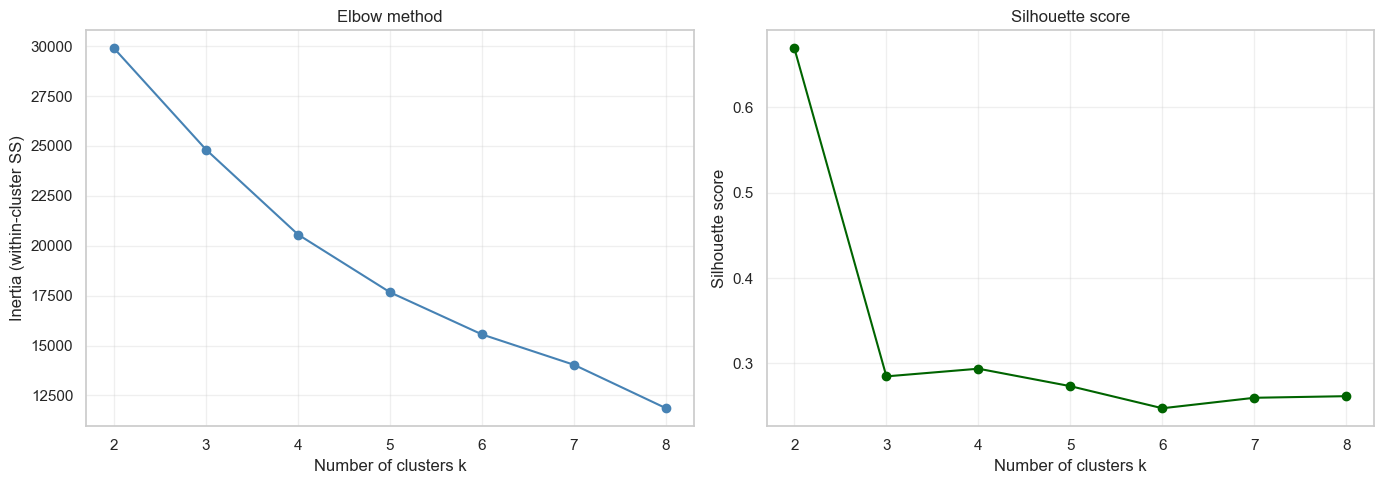

 k |    inertia | silhouette
------------------------------
 2 |      29893 |      0.669
 3 |      24817 |      0.285
 4 |      20561 |      0.294
 5 |      17666 |      0.273
 6 |      15555 |      0.248
 7 |      14033 |      0.260
 8 |      11857 |      0.262


In [156]:
# Cell 3 — Choose the number of regimes: elbow method + silhouette score

X = pca_scores.values   # the 5 PCA components per day

k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Plot both diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(k_range), inertias, marker="o", color="steelblue")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Inertia (within-cluster SS)")
ax.set_title("Elbow method")
ax.grid(alpha=0.3)  

ax = axes[1]
ax.plot(list(k_range), silhouettes, marker="o", color="darkgreen")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'k':>2} | {'inertia':>10} | {'silhouette':>10}")
print("-" * 30)
for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"{k:>2} | {i:>10.0f} | {s:>10.3f}")

We don't have an obvious answer here. The elbow bends gently around 3–4, while the silhouette score is actually highest at k=2. But k=2 just splits "calm" from everything else. 

So we go with **k=4**: a trade-off between the pure statistics (which lean toward 2) and economic usefulness (which needs more granularity). The real test isn't the silhouette anyway it's whether the four groups turn out to be interpretable and to separate the DFL.

Let's now run the Kmeans with k=4

In [157]:
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
regime_labels = kmeans.fit_predict(pca_scores.values)

# Attach labels to the dates
regimes = pd.Series(regime_labels, index=pca_scores.index, name="regime")

print(f"K-means fitted with k={k}\n")
print("Days per regime:")
counts = regimes.value_counts().sort_index()
for r, n in counts.items():
    print(f"  Regime {r}: {n:>5} days ({n / len(regimes) * 100:.1f}%)")

K-means fitted with k=4

Days per regime:
  Regime 0:  1964 days (64.7%)
  Regime 1:   138 days (4.5%)
  Regime 2:    12 days (0.4%)
  Regime 3:   921 days (30.3%)


Okay we have 4 very uneven regimes. Let's try to understand what they could mean physicaly.

Regime centroids (mean position on each PC):

            PC1    PC2     PC3    PC4    PC5
Regime 0  0.380 -0.380  -0.140  0.010  0.140
Regime 1  7.770  1.060   2.180 -0.890  0.880
Regime 2 17.400  6.730 -13.320  1.880 -4.140
Regime 3 -2.200  0.560   0.150  0.100 -0.380


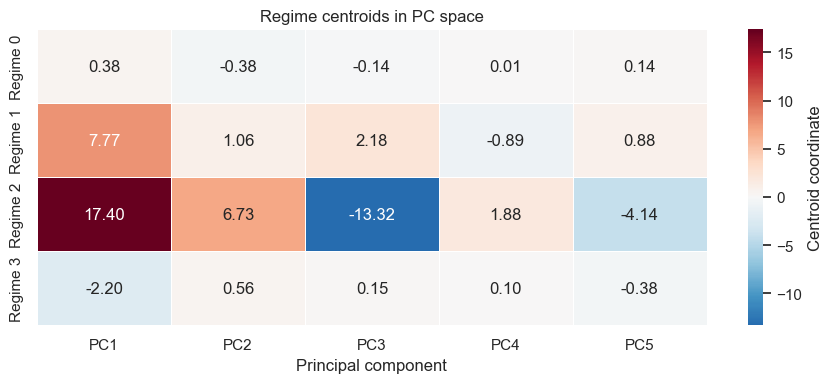

In [158]:

# Cell 5 — Interpret regimes via their centroids in PC space

centroids = pd.DataFrame(
    kmeans.cluster_centers_,  
    columns=pca_scores.columns,
    index=[f"Regime {i}" for i in range(k)],
)
print("Regime centroids (mean position on each PC):\n")
print(centroids.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(centroids, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Centroid coordinate"}, ax=ax)
ax.set_title("Regime centroids in PC space")
ax.set_xlabel("Principal component")
plt.tight_layout()  
plt.show()

## Regime interpretation

**Regime 0 — Calm / normal (65%)**: near the origin on all components. Mild backwardation, low volatility (PC2 negative). The baseline market state.

**Regime 3 — Contango / oversupply (30%)**: PC1 is negative → the curve is in contango (well-supplied, "heavy" physical market). The bearish-physical counterpart of the calm regime.

**Regime 1 — Physical tightness (4.5%)**: strong backwardation (PC1  =+7.8), moderate volatility, Brent rich vs Dubai (PC3 = +2.2). 

**Regime 2 — Crisis (0.4%, 12 days)**: every dimension is extreme simultaneously. Extreme backwardation (PC1 = +17.4), extreme volatility / risk-off (PC2 = +6.7), violent East-West dislocation (PC3 = −13.3), macro shock in progress (PC4 = +1.9).


The regime structure is economically coherent: it maps onto how a physical trader
reads the market — from oversupplied (contango), through normal, to tight
(backwardation), to crisis. The regimes were found **without ever looking at the
DFL** (the target was excluded from clustering), so the next step validates whether
they separate the DFL distribution out-of-sample.


However, having a regime with only 0.4% of points seems a bit off to us, let's plot the DFL graph with the different regimes.

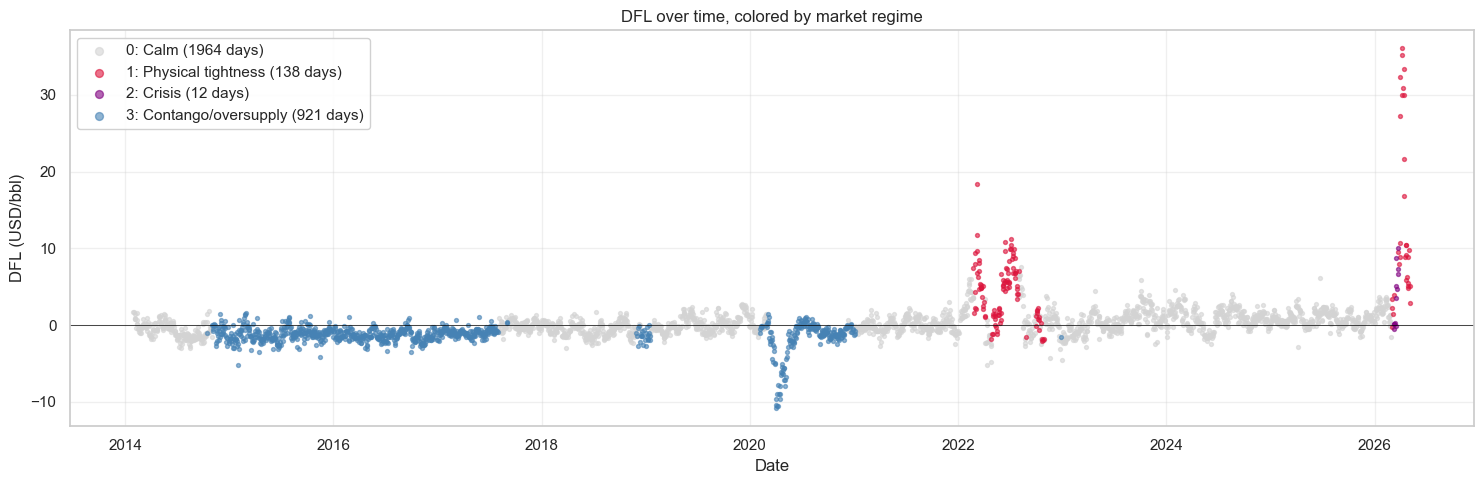

In [159]:
regime_names = {
      0: "Calm",
      1: "Physical tightness",
      2: "Crisis",
      3: "Contango/oversupply",
}

regime_colors = {
    0: "lightgray",    # Calm
    1: "crimson",      # Physical tightness
    2: "purple",       # East-West dislocation
    3: "steelblue",    # Contango / oversupply
}

fig, ax = plt.subplots(figsize=(15, 5))

for r in sorted(regimes.unique()):
    mask = regimes == r
    dates_r = regimes.index[mask]
    dfl_r = df.loc[dates_r, "DFL"]
    ax.scatter(dates_r, dfl_r, s=8, c=regime_colors[r], alpha=0.6,
                label=f"{r}: {regime_names[r]} ({mask.sum()} days)")

ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("DFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("DFL over time, colored by market regime")
ax.legend(loc="upper left", markerscale=2, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As we can see, the "crisis" regime is occuring only during the current Hormuz crisis. 

We thus prefer to change k to 3, it makes more sense statisticaly and physicaly. According to us we should have one regime representing contango periods, one for backwardation periods and another one representing crisis. 

K-means fitted with k=3

Days per regime:
  Regime 0:   929 days (30.6%)
  Regime 1:  1990 days (65.6%)
  Regime 2:   116 days (3.8%)
Regime centroids (mean position on each PC):

            PC1    PC2    PC3    PC4    PC5
Regime 0 -2.190  0.550  0.150  0.090 -0.380
Regime 1  0.450 -0.350 -0.110  0.000  0.150
Regime 2  9.800  1.570  0.700 -0.820  0.420


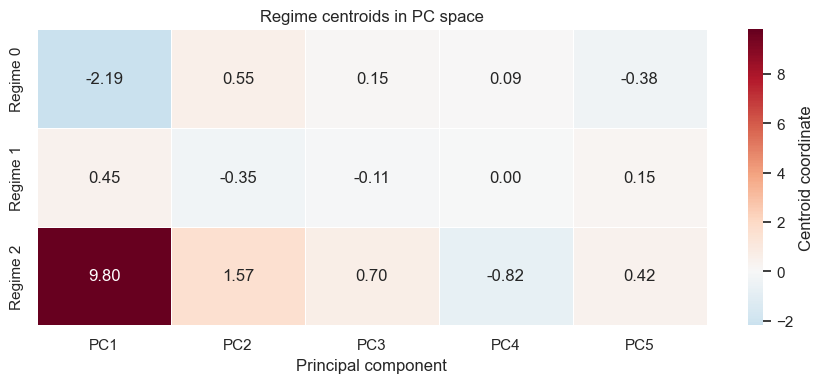

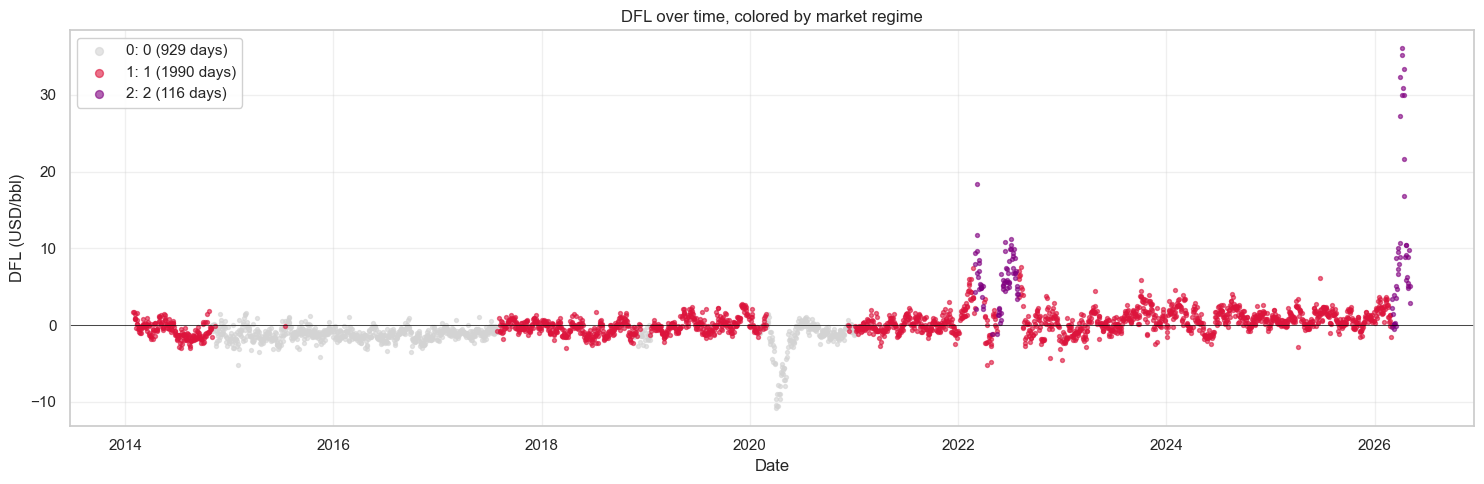

In [160]:
k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
regime_labels = kmeans.fit_predict(pca_scores.values)

# Attach labels to the dates
regimes = pd.Series(regime_labels, index=pca_scores.index, name="regime")

print(f"K-means fitted with k={k}\n")
print("Days per regime:")
counts = regimes.value_counts().sort_index()
for r, n in counts.items():
    print(f"  Regime {r}: {n:>5} days ({n / len(regimes) * 100:.1f}%)")

regime_names = {
      0: "0",
      1: "1",
      2: "2",
}


centroids = pd.DataFrame(
    kmeans.cluster_centers_,  
    columns=pca_scores.columns,
    index=[f"Regime {i}" for i in range(k)],
)
print("Regime centroids (mean position on each PC):\n")
print(centroids.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(centroids, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Centroid coordinate"}, ax=ax)
ax.set_title("Regime centroids in PC space")
ax.set_xlabel("Principal component")
plt.tight_layout()  
plt.show()


regime_colors = {
    0: "lightgray",    # Calm
    1: "crimson",      # Physical tightness
    2: "purple",       # East-West dislocation
}

fig, ax = plt.subplots(figsize=(15, 5))

for r in sorted(regimes.unique()):
    mask = regimes == r
    dates_r = regimes.index[mask]
    dfl_r = df.loc[dates_r, "DFL"]
    ax.scatter(dates_r, dfl_r, s=8, c=regime_colors[r], alpha=0.6,
                label=f"{r}: {regime_names[r]} ({mask.sum()} days)")

ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("DFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("DFL over time, colored by market regime")
ax.legend(loc="upper left", markerscale=2, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


It seems better.

## Regime interpretation

- **Regime 0 — Contango.** Negative PC1 → the curve is in contango, a heavy, well-supplied
physical market. This is where the DFL **downside** lives: the 2015-16 glut and the 2020
COVID
crash (the −$10.8 floor).   
- **Regime 1 — Calm.** Sits near the origin on everything — mild structure, low vol. The
market's
default state, two-thirds of all days, DFL hugging zero.
- **Regime 2 — Physical tightness.** Strong backwardation (PC1 = +9.8) with vol picking
up. This
is where the DFL **upside** lives — the 2022 Russia squeeze and the 2026 spike (DFL to
+$36).


One strange result at first is that COVID is not in the crisis regime but in reality when we plot the vol during that period, it wasn't extreme and the decision of regime is mainly made by PC1 which represent the curent structure. It makes sense to us for it to be in the Regime 0.


Let's plot the DFL realised vol to confirm our COVID conclusion : 

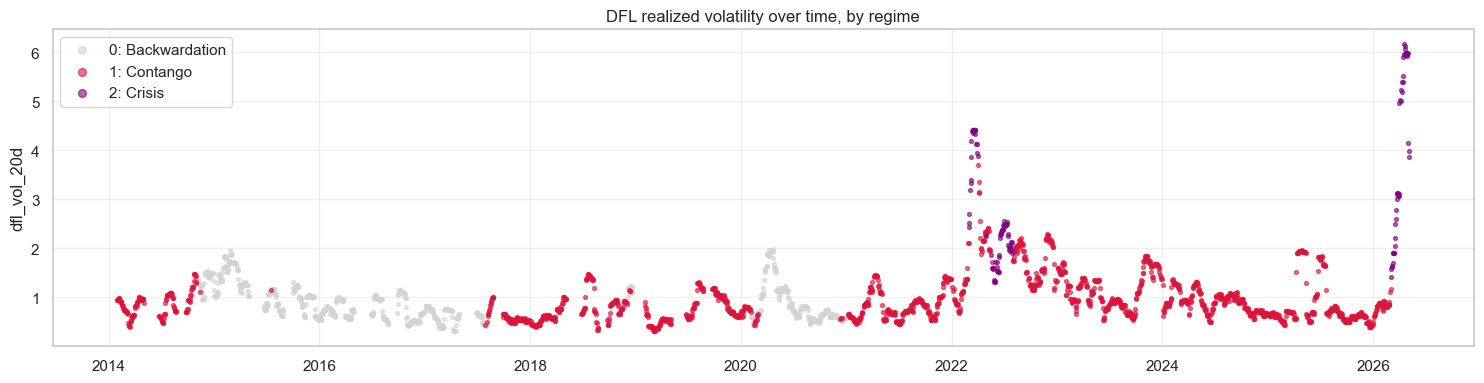

In [163]:
fig, ax = plt.subplots(figsize=(15, 4))
for r in sorted(regimes.unique()):
    mask = regimes == r
    ax.scatter(regimes.index[mask], df.loc[regimes.index[mask], "dfl_vol_20d"],
                s=8, c=regime_colors[r], alpha=0.6, label=f"{r}: {regime_names[r]}")
ax.set_ylabel("dfl_vol_20d")
ax.set_title("DFL realized volatility over time, by regime")
ax.legend(loc="upper left", markerscale=2)
ax.grid(alpha=0.3)  
plt.tight_layout()
plt.show()

Conslusion confirmed, let's continue by confirming the three regimes by wondering if the DFL distribution actually differ across the three?

=== DFL distribution per regime ===

Regime                         N    mean     std      p1     p99     min     max
--------------------------------------------------------------------------------
0 Contango                   919   -1.28    1.41   -7.93   +1.05  -10.81   +1.54
1 Calm                      1980   +0.29    1.38   -2.44   +4.34   -5.13   +7.59
2 Physical tightness         116   +7.84    7.57   -1.02  +34.88   -1.18  +36.05


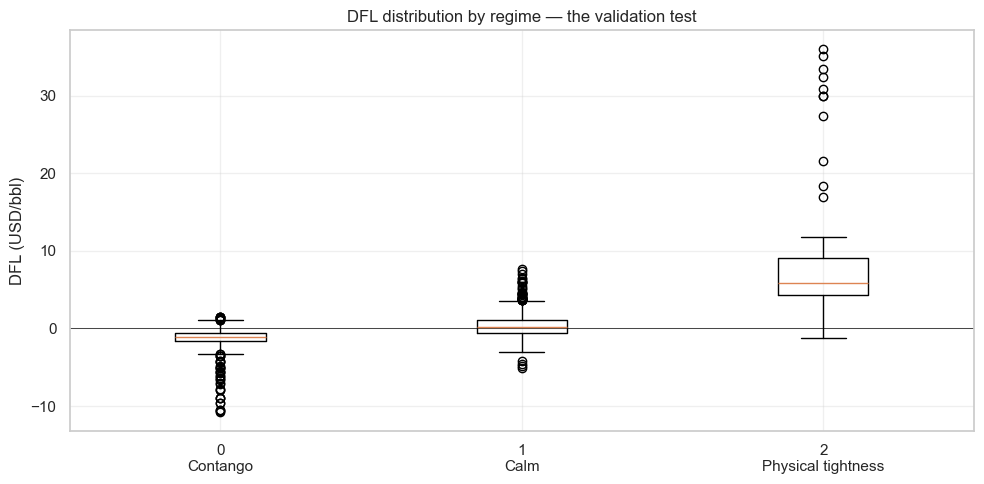

In [166]:
# Validation: does the DFL distribution differ across regimes?

regime_names = {
      0: "Contango",
      1: "Calm",
      2: "Physical tightness",
}

# Combine regime labels with DFL (drop the ~20 Platts-holiday NaN)
val = pd.DataFrame({"regime": regimes, "DFL": dfl}).dropna()

print("=== DFL distribution per regime ===\n")
print(f"{'Regime':<26}{'N':>6}{'mean':>8}{'std':>8}{'p1':>8}{'p99':>8}{'min':>8}{'max':>8}")
print("-" * 80)
for r in sorted(val["regime"].unique()):
    sub = val.loc[val["regime"] == r, "DFL"]
    name = f"{r} {regime_names[r]}"
    print(f"{name:<26}{len(sub):>6}{sub.mean():>+8.2f}{sub.std():>8.2f}"
        f"{sub.quantile(0.01):>+8.2f}{sub.quantile(0.99):>+8.2f}"
        f"{sub.min():>+8.2f}{sub.max():>+8.2f}")

# Boxplot of DFL by regime
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(val["regime"].unique())
data_by_regime = [val.loc[val["regime"] == r, "DFL"] for r in order]
tick_labels = [f"{r}\n{regime_names[r]}" for r in order]

ax.boxplot(data_by_regime, tick_labels=tick_labels, showfliers=True)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("DFL (USD/bbl)")
ax.set_title("DFL distribution by regime — the validation test")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Regime 0 (Contango) — box sits below zero with a long stack of outliers diving to −$10.
Downside tail, almost no upside. 
- Regime 1 (Calm) — tight little box hugging zero, symmetric, modest whiskers. The benign
middle. 
- Regime 2 (Physical tightness) — box lifted up (median ~$5), with a tail of outliers
climbing all the way to +$36, and the lower whisker barely below zero. Pure upside tail. 

The three boxes barely share the same vertical space and the tails point in opposite 
directions (0 down, 2 up). That's the asymmetric, directional separation the conclusion
describes, and it's the whole validation: regimes built without ever seeing the DFL still
carve it into "downside / neutral / upside" buckets.

In [167]:
# Save regime labels for the VaR model (notebook 04)

from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(exist_ok=True)

# Save the regime label per date
regimes.to_frame().to_pickle(out_dir / "regime_labels.pkl")
regimes.to_frame().to_csv(out_dir / "regime_labels.csv")

print(f"Saved regime labels: {len(regimes)} days "
    f"({regimes.index.min().date()} → {regimes.index.max().date()})")
print(f"  → {out_dir}/regime_labels.pkl + .csv\n")
print("Regime mapping:")
for r, name in regime_names.items():
    print(f"  {r}: {name}")

Saved regime labels: 3035 days (2014-01-30 → 2026-05-06)
  → ../data/processed/regime_labels.pkl + .csv

Regime mapping:
  0: Contango
  1: Calm
  2: Physical tightness


Starting from the 5 PCA components, K-means gave us **3 market regimes**: Contango (30%),
  Calm
  (66%), and Physical tightness (4%). We landed on k=3 deliberately — k=2 ("normal vs
  stressed")
  would have lumped contango and tightness together and lost *which way* the risk points,
  while
  the k=4 split produced a fragile 12-day cluster that added little. Three seems the sweet
  spot.

 The regimes were built from market structure alone, the
  DFL was never shown to the clustering. Yet they carve the DFL into three clean,
  *asymmetric*
  buckets: contango carries the **downside** (to −$11), tightness the **upside** (to +$36),
  calm
  sits tight in the middle. That asymmetry is the same +5.5 skew from notebook 01, now
  *explained*
  rather than just measured. It's the core thesis confirmed: the DFL distribution is
  regime-dependent, so a regime-conditional VaR is justified.
  
  And the regimes are economically real, with no event labels given to the model.
  Contango  
  captures the 2014-16 glut and the 2020 COVID crash; tightness starts on Russia's 2022
  invasion
  and recurs in the 2026 spike. The unsupervised model will rediscover the market's
  history.
  
However, a discrete label is coarse and that's the bridge to notebook 04. The regime
  gives
  *direction*, not *magnitude*: COVID and a sleepy 2016 contango day share the "contango"
  label
  despite very different conditions, and the regime alone can't tell them apart. That's
  exactly
  what the continuous model fixes. In notebook 04, XGBoost takes this regime label as its
  top
  feature and layers the continuous features (realized vol, curve, macro) on top, so it can
  widen
  or tighten the VaR *within* a regime. Direction from the regime, magnitude from XGBoost.

